# Assignment 8: Pandas Groupby with Hurricane Data

Import Numpy, Pandas and Matplotlib and set the display options.

Use the following code to load a CSV file of the NOAA IBTrACS hurricane dataset:

In [1]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


Basin Key: (NI - North Indian, SI - South Indian, WP - Western Pacific, SP - Southern Pacific, EP - Eastern Pacific, NA - North Atlantic)

How many rows does this dataset have?

How many North Atlantic hurricanes are in this dataset?

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716165 entries, 0 to 716164
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       716165 non-null  object        
 1   SEASON    716165 non-null  int64         
 2   NUMBER    716165 non-null  int64         
 3   BASIN     716165 non-null  object        
 4   SUBBASIN  716165 non-null  object        
 5   NAME      390393 non-null  object        
 6   ISO_TIME  716165 non-null  datetime64[ns]
 7   NATURE    716165 non-null  object        
 8   LAT       716165 non-null  float64       
 9   LON       716165 non-null  float64       
 10  WMO_WIND  157570 non-null  float64       
 11  WMO_PRES  160275 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 65.6+ MB


In [3]:
len(df)

716165

In [4]:
(df['BASIN'] == 'NA').sum()

126392

There are 716165 rows and 126392 North Atlantic hurricanes in the dataset.

1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [5]:
print("Unique values of the BASIN column:", df['BASIN'].unique())

Unique values of the BASIN column: ['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']


In [6]:
print("Unique values of the SUBBASIN column:", df['SUBBASIN'].unique())

Unique values of the SUBBASIN column: ['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']


In [7]:
print("Unique values of the NATURE column:", df['NATURE'].unique())

Unique values of the NATURE column: ['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [8]:
df = df.rename(columns={"WMO_WIND": "WIND", "WMO_PRES": "PRES"})

In [9]:
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


3) Get the 10 largest rows in the dataset by WIND.
You will notice some names are repeated.

In [10]:
df.nlargest(10,'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


4) Group the data on SID and get the 10 largest hurricanes by WIND

In [11]:
top10 = df.groupby('SID')['WIND'].max().nlargest(10)
print('The 10 largest hurricanes by wind speed (knots): ')
top10

The 10 largest hurricanes by wind speed (knots): 


SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

In [12]:
top10names = df.groupby('NAME')['WIND'].max().nlargest(10)
top10names

NAME
PATRICIA    185.0
ALLEN       165.0
DORIAN      160.0
GILBERT     160.0
LINDA       160.0
WILMA       160.0
IRMA        155.0
MITCH       155.0
RICK        155.0
RITA        155.0
Name: WIND, dtype: float64

5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes.
Use the name on the x-axis.



<Axes: title={'center': 'Wind Speeds of the 20 Strongest-Wind Hurricanes'}, xlabel='NAME', ylabel='Wind Speed (Knots)'>

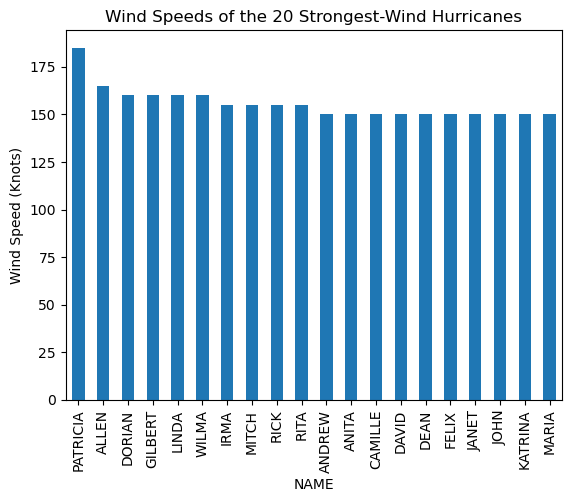

In [13]:
df.groupby('NAME')['WIND'].max().nlargest(20).plot(kind = 'bar',ylabel = 'Wind Speed (Knots)', title = 'Wind Speeds of the 20 Strongest-Wind Hurricanes')

6) Plot the count of all datapoints by Basin
as a bar chart

<Axes: title={'center': 'Counts of All Datapoints by Basin'}, xlabel='BASIN', ylabel='Counts'>

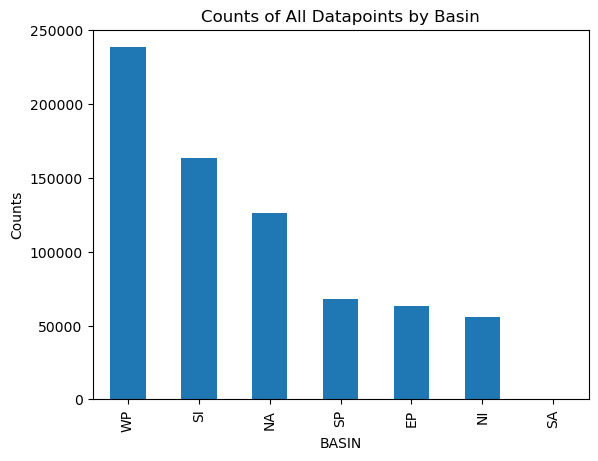

In [14]:
df.groupby('BASIN').size().sort_values(ascending = False).plot(kind = 'bar',ylabel = 'Counts', title = 'Counts of All Datapoints by Basin')

7) Plot the count of unique hurricanes by Basin
as a bar chart.



<Axes: title={'center': 'Count of Unique Hurricanes by Basin'}, xlabel='BASIN', ylabel='Count of Unique Hurricanes'>

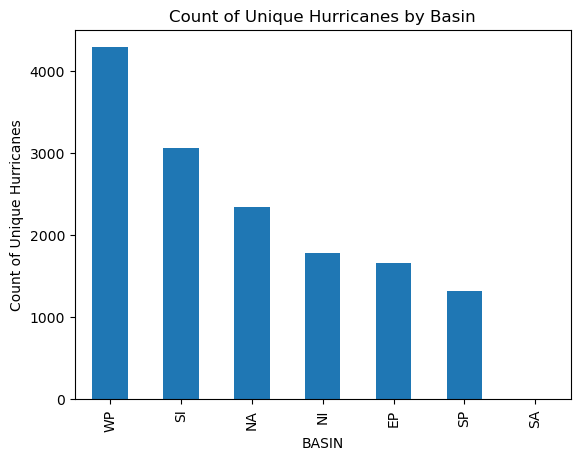

In [15]:
df.groupby('BASIN')['SID'].nunique().sort_values(ascending = False).plot(kind = 'bar',ylabel = 'Count of Unique Hurricanes',title = 'Count of Unique Hurricanes by Basin')

8) Make a hexbin of the location of datapoints in Latitude and Longitude
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.hexbin.html

<Axes: title={'center': 'Hexbin of the Locations of Datapoints \nColored by the Count of Datapoints'}, xlabel='LON', ylabel='LAT'>

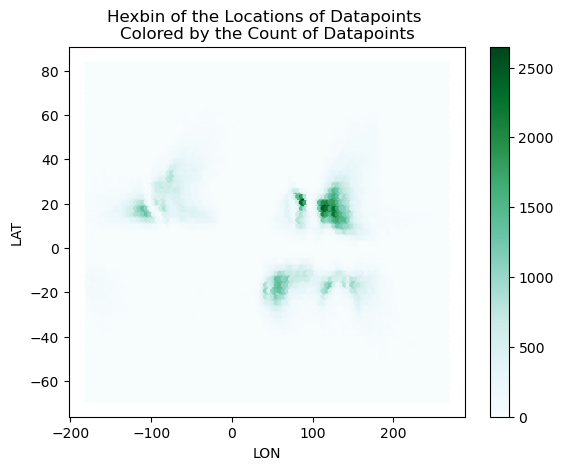

In [16]:
df.plot.hexbin(x="LON", y="LAT",title = 'Hexbin of the Locations of Datapoints \nColored by the Count of Datapoints')

9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot.
First find the SID of this hurricane.

Next get this hurricane’s group and plot its position as a scatter plot. Use wind speed to color the points.

In [17]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID']

603763    2005236N23285
603764    2005236N23285
603765    2005236N23285
603766    2005236N23285
603767    2005236N23285
              ...      
603822    2005236N23285
603823    2005236N23285
603824    2005236N23285
603825    2005236N23285
603826    2005236N23285
Name: SID, Length: 64, dtype: object

In [18]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].unique()

array(['2005236N23285'], dtype=object)

<Axes: title={'center': 'Hurricane Katrina (2005) Track \n with Points Colored by Wind Speed'}, xlabel='Longitude', ylabel='Latitude'>

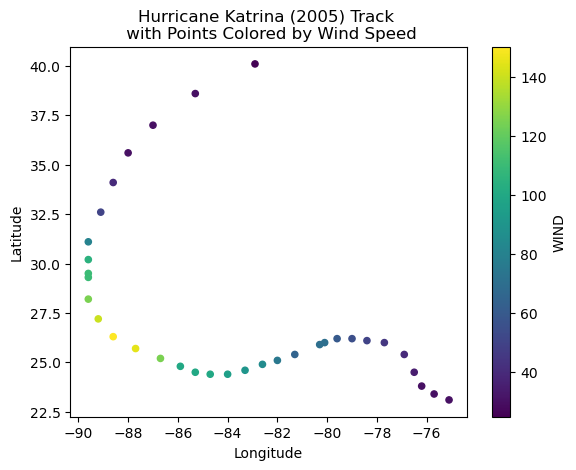

In [19]:
df[df['SID'] == '2005236N23285'].plot.scatter(x='LON',
                                              y='LAT', 
                                              c = 'WIND',
                                              xlabel = 'Longitude', 
                                              ylabel = 'Latitude', 
                                              title = 'Hurricane Katrina (2005) Track \n with Points Colored by Wind Speed')

10) Make time the index on your dataframe

In [20]:
df_index = df.set_index('ISO_TIME')

In [21]:
df_index.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


11) Plot the count of all datapoints per year as a timeseries.
You should use resample https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

Which years stand out as having anomalous hurricane activity?

<Axes: title={'center': 'Hurricane Datapoints Per Year'}, xlabel='Year', ylabel='Count'>

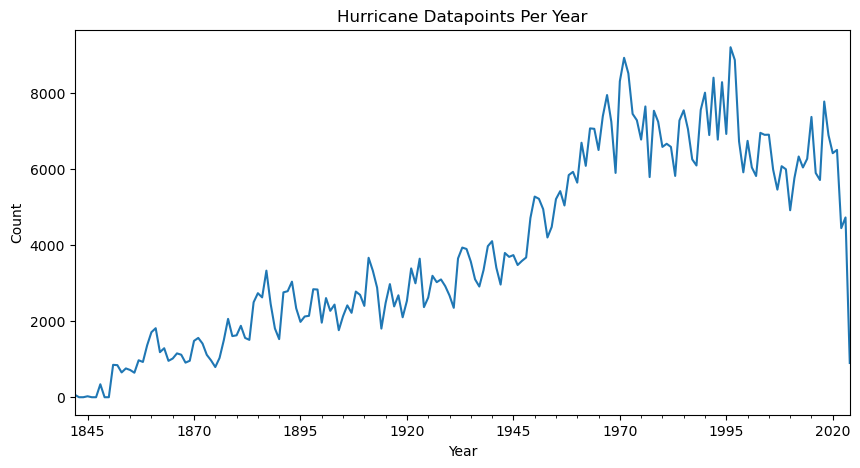

In [22]:
df_index.resample('YE').size().plot(title='Hurricane Datapoints Per Year', xlabel = 'Year', ylabel = 'Count', figsize=(10, 5))

In [23]:
df_index.resample('YE').size().nlargest(5)

ISO_TIME
1996-12-31    9189
1971-12-31    8911
1997-12-31    8854
1972-12-31    8503
1992-12-31    8389
dtype: int64

In [24]:
df_index.resample('YE').size().nsmallest(10)

ISO_TIME
1843-12-31      0
1844-12-31      0
1846-12-31      0
1847-12-31      0
1849-12-31      0
1850-12-31      0
1845-12-31     25
1842-12-31     65
1848-12-31    340
1856-12-31    643
dtype: int64

The years 1996 and 1971 have anomalous hurricane activity, with the hurricane count exceeding 8900 for each of those years.

There are zero hurricanes recorded for several years in the 1840s, but this is likely due to a lack of data.